In [1]:
from collections import Counter
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import skew
from scipy.stats import mode
import numpy as np
import pandas as pd
print('started')
np.random.seed(1)

started


# Probability

## Conditional Probability

In [2]:
# P_A_given_B
# Total Students = 20
# Total Boys = 5
# Boys passed = 2
# Find probability of boy
B=5
B_Passed=2
P_B_Given_B_Passed=B_Passed/B
print(P_B_Given_B_Passed)

0.4


## Bayes Theorem

In [3]:
# Probability of D = 0.01
# Probability of Pos given D = 0.9
# Probability of Positive given No D = 0.1
P_D = 0.01
P_Pos_Given_D = 0.9
P_Pos_Given_No_D = 0.1
P_No_D = 1-P_D
# Find P(D|Pos)
# P(D|Pos) = [P(Pos|D)*P(D)]/P(Pos)
P_Pos=P_Pos_Given_D*P_D + P_Pos_Given_No_D*P_No_D
P_D_Given_Pos= (P_Pos_Given_D*P_D)/P_Pos
print(P_D_Given_Pos)

0.08333333333333333


## Random Variable ||||||||||||||||

## Probability Distributions

In [4]:
d=[1,2,1,2,3,2,4,43,9,6,1,2,4,3,1,8,3,2,4,2,7,5,4,5,3,5,4,5,6,3,5]
d_copy=d.copy()

### Normal Distribution

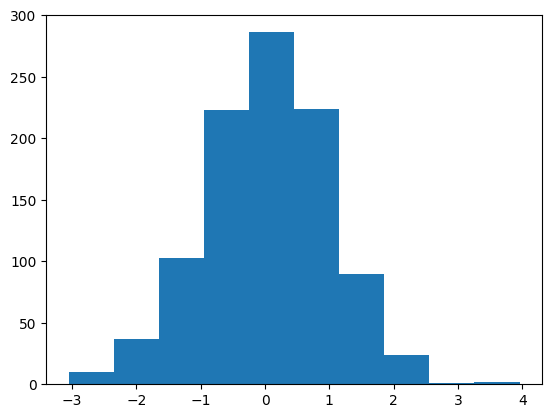

In [5]:
nd=np.random.normal(0,1,1000)
plt.hist(nd)
plt.show()

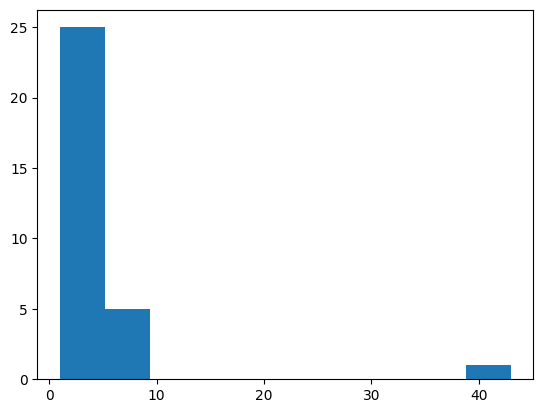

In [6]:
plt.hist(d)
plt.show(d)

# Descriptive Statistics

## Measures of central tendency

### Mean

In [7]:
mean=sum(d)/len(d)

print(mean)
print(np.mean(d))

5.0
5.0


### Median

In [8]:
d.sort()
q2=median=(d[len(d)//2-1]+d[len(d)//2])/2 if len(d)%2==0 else d[len(d)//2]

print(median)
print(np.median(d))

4
4.0


### Mode

In [9]:
mode=[]
freq=Counter(d)
max_count=0
for count in freq.values():
    if count > max_count:
        max_count=count
for val,count in freq.items() if max_count>1 else []:
    if count==max_count:
        mode.append(val)

print(mode)
print(stats.mode(d))

[2]
ModeResult(mode=np.int64(2), count=np.int64(6))


## Measure of Dispersion

### Range

In [10]:
print(max(d)-min(d))

42


### Variance

In [11]:
d_cen=d-np.mean(d)
print(d_cen)

[-4. -4. -4. -4. -3. -3. -3. -3. -3. -3. -2. -2. -2. -2. -2. -1. -1. -1.
 -1. -1.  0.  0.  0.  0.  0.  1.  1.  2.  3.  4. 38.]


In [12]:
vr=sum([x**2 for x in d_cen])/len(d_cen)

print('variance',vr)
print('np variance', np.var(d))

variance 52.193548387096776
np variance 52.193548387096776


### Standard deviation

In [13]:
print('standard deviation', vr**0.5)
print('np standard deviation', np.std(d))

standard deviation 7.224510252404434
np standard deviation 7.224510252404434


## Skewness

In [14]:
print(skew(d))

4.6632559499876765


## Kurtosis ||||||||||||

## Finding outliers

### Finding the Interquartile Range

In [15]:
fh=d[:len(d)//2]
sh=d[len(d)//2 if len(d)%2==0 else len(d)//2+1:]
print(fh)
print(sh)

[1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3]
[4, 4, 4, 4, 5, 5, 5, 5, 5, 6, 6, 7, 8, 9, 43]


In [16]:
q1=fh_median=(fh[len(fh)//2]+fh[len(fh)//2-1])/2 if len(fh)%2==0 else fh[len(fh)//2]
q3=sh_median=(sh[len(sh)//2]+sh[len(sh)//2-1])/2 if len(sh)%2==0 else sh[len(sh)//2]
iqr=q3-q1
iqr

3

In [17]:
lower=q1-1.5*iqr
upper=q3+1.5*iqr

print('Lower',lower)
print('Upper',upper)

Lower -2.5
Upper 9.5


### Finding the ourlier

In [18]:
print('Outliers are: ',end='')
for i in d:
    if i>upper or i<lower:
        print(i,end=', ')

Outliers are: 43, 

## Data Visualization

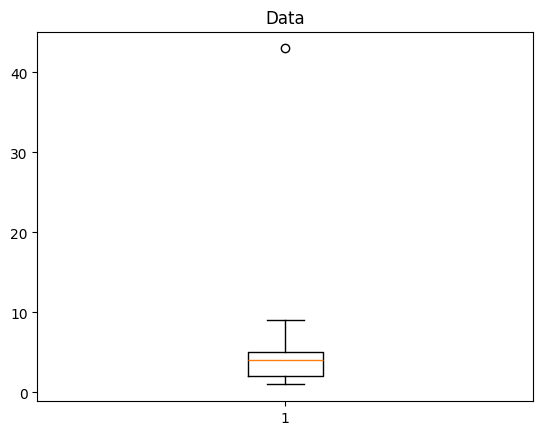

In [19]:
plt.boxplot(d)
plt.title('Data')
plt.show()

### Handling the outlier by replacing

In [20]:
data=d.copy()
for i in range(len(d)):
    if data[i]>upper or data[i]<lower:
        data[i]=q2
print(data)

[1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 4, 4, 4, 4, 4, 5, 5, 5, 5, 5, 6, 6, 7, 8, 9, 4]


# Inferential Statistics

In [21]:
np.random.shuffle(data)
d=data
print(d)

[2, 4, 5, 3, 3, 2, 9, 2, 5, 4, 2, 5, 5, 2, 4, 4, 1, 1, 1, 3, 5, 8, 4, 3, 3, 6, 7, 6, 4, 2, 1]


## Sampling Techniques

### Random Sampling

In [22]:
d_randsam=np.random.choice(d,size=10)
print(d_randsam)

[2 5 3 2 2 2 1 6 5 6]


### Statrified Sampling

In [23]:
data=np.array(d)
d_stratsam_low=data[data<=4]
d_stratsam_mid=data[(data>4) & (data<=7)]
d_stratsam_high=data[data>7]
d_stratsam_low_ch=np.random.choice(d_stratsam_low, size=2)
d_stratsam_mid_ch=np.random.choice(d_stratsam_mid, size=2)
d_stratsam_high_ch=np.random.choice(d_stratsam_high, size=2)
d_stratsam=np.concatenate([d_stratsam_low_ch, d_stratsam_mid_ch, d_stratsam_high_ch])
print(d_stratsam)

[3 2 5 5 9 9]


### Symmetric Sampling

In [24]:
d_symsam=d[::3]
print(d_symsam)

[2, 3, 9, 4, 5, 4, 1, 8, 3, 6, 1]


### Cluster Sampling

In [25]:
d_clussam_a=data[data<=4]
d_clussam_b=data[(data>4) & (data<=7)]
d_clussam_c=data[data>7]
clusters={
    'A':d_clussam_a,
    'B':d_clussam_b,
    'C':d_clussam_c
}
d_clussam_ch=np.random.choice(list(clusters.keys()),size=2,replace=False)
d_clussam=[]
for ch in d_clussam_ch:
    d_clussam.extend(clusters[ch])
print(d_clussam)

[np.int64(5), np.int64(5), np.int64(5), np.int64(5), np.int64(5), np.int64(6), np.int64(7), np.int64(6), np.int64(9), np.int64(8)]


### Convinience Sampling

In [26]:
d_consam=d[:10]
print(d_consam)

[2, 4, 5, 3, 3, 2, 9, 2, 5, 4]


## Point Estimation

In [27]:
# Calculating a single value from a sample to estimate the population parameter
print(np.mean(d_consam))

3.9


## Interval Estimation

In [28]:
sem=stats.sem(d_consam)
ci=stats.norm.interval(0.95, loc=np.mean(d_consam), scale=sem)
print('Mean',np.mean(d_consam))
print('Confidence Interval 95%',ci)

Mean 3.9
Confidence Interval 95% (np.float64(2.578739382397798), np.float64(5.221260617602201))


## Confidence Interval


Confidence interval is a specific type of interval estimate that includes a confidence level indicating how often the interval would contain the true parameter if repeated

In [29]:
sem=stats.sem(d_copy)
print('Mean',np.mean(d_copy))
ci = stats.norm.interval(0.95, loc=np.mean(d_copy), scale=sem)
print('Confidence interval 95%', ci)
ci = stats.norm.interval(0.45, loc=np.mean(d_copy), scale=sem)
print('Confidence interval 45%', ci)
ci = stats.norm.interval(0.25, loc=np.mean(d_copy), scale=sem)
print('Confidence interval 25%', ci)

Mean 5.0
Confidence interval 95% (np.float64(2.414789713034685), np.float64(7.5852102869653155))
Confidence interval 45% (np.float64(4.21154896764833), np.float64(5.78845103235167))
Confidence interval 25% (np.float64(4.579711786517293), np.float64(5.420288213482707))


# Hypothesis Testing

In [30]:
from statsmodels.stats.weightstats import ztest
from scipy.stats import ttest_1samp

## Z Test

### From Scratch

In [31]:
data = [48, 52, 49, 51, 47]
mean=np.mean(data)
n=len(data)

In [32]:
sigma=2
mu=50
z_stat=(mean-mu)/(sigma/np.sqrt(n))
p_value=2*(1-stats.norm.cdf(abs(z_stat)))
print('z_stat',z_stat)
print('p_value',p_value)

z_stat -0.6708203932499385
p_value 0.5023349543605011


### Library

In [33]:
z_stat,p_value=ztest(data,value=50)
print('z_stat',z_stat)
print('p_value',p_value)

z_stat -0.646996639220632
p_value 0.5176341185833445


## T Test

### From Scratch

In [34]:
s=np.std(data,ddof=1)
t_stat=(mean-mu)/(s/np.sqrt(n))
p_value=2*(1-stats.t.cdf(abs(t_stat),df=n-1))
print('z_stat',z_stat)
print('p_value',p_value)

z_stat -0.646996639220632
p_value 0.5528894339334163


### Library

In [35]:
t_stat,p_value=ttest_1samp(data,50)
print('z_stat',z_stat)
print('p_value',p_value)

z_stat -0.646996639220632
p_value 0.5528894339334163


## Chi-Square Test

### From Scratch

In [36]:
expected=np.array([50,50])
observed=np.array([60,40])
chi_stat=np.sum((observed-expected)**2/expected)
df=len(observed)-1
p_value= 1 - stats.chi2.cdf(chi_stat,df)
print('z_stat',z_stat)
print('p_value',p_value)

z_stat -0.646996639220632
p_value 0.04550026389635853


### Library ||||||||||||||||

## Anova

### One-Way Anova

#### From Scratch

In [38]:
a=[1,2]
b=[3,4]
c=[5,6]
s=a+b+c
print(s)

[1, 2, 3, 4, 5, 6]
